In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df=pd.read_csv("customer_behavior.csv")
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


1. What is the average, median, and mode of PurchaseAmount?


In [4]:
mean = df["PurchaseAmount"].mean()
median = df["PurchaseAmount"].median()
mode = df["PurchaseAmount"].mode()[0]
 
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 1003.9506701030928
Median: 998.0799999999999
Mode: 0.0


2. Are there any outliers in the PurchaseAmount data?


In [5]:
Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)
 
IQR = Q3 - Q1
 
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
 
outliers = df[
    (df["PurchaseAmount"] < lower_limit) |
    (df["PurchaseAmount"] > upper_limit)
]
 
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))
print(outliers)

Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower Limit: -306.51000000000033
Upper Limit: 2307.2300000000005
Number of Outliers: 15
      CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
195         1196    Male   West         2318.33         Fashion   Yes   
265         1266  Female   East         2496.41     Electronics   Yes   
348         1349    Male  South         2688.69     Electronics   Yes   
411         1412  Female  South         2349.16         Fashion   Yes   
826         1827    Male   East         2578.89     Electronics   Yes   
1358        2359    Male   West         2384.19     Electronics   Yes   
2285        3286    Male   East         2457.05         Grocery    No   
2557        3558    Male   East         2316.19         Fashion   Yes   
2681        3682  Female   East         2400.69         Fashion   Yes   
3326        4327  Female  North         2357.41         Grocery    No   
3438        4439  Female   East         2688.88   

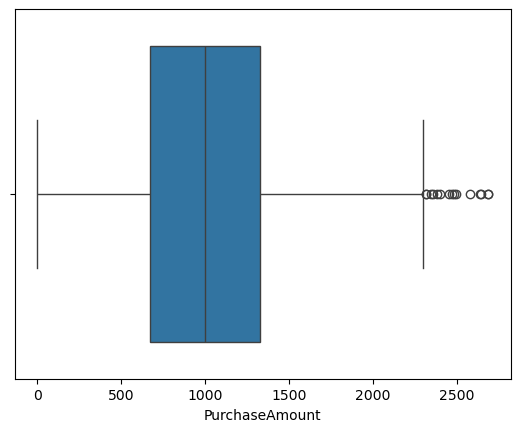

In [6]:
sns.boxplot(x=df["PurchaseAmount"])
plt.show()

3. Is there any skewness or kurtosis in the PurchaseAmount distribution?


In [7]:
skewness = df["PurchaseAmount"].skew()
kurtosis = df["PurchaseAmount"].kurt()
 
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


4. Is there a significant difference in spending between male and female
customers?


In [18]:
male = df[df["Gender"] == "Male"]["PurchaseAmount"].dropna()
female = df[df["Gender"] == "Female"]["PurchaseAmount"].dropna()
 
t_stat, p_value = stats.ttest_ind(male, female)
 
print("T-statistic:", t_stat)
print("P-value:", p_value)
 
if p_value < 0.05:
    print("There is a significant difference in spending.")
else:
    print("There is no significant difference in spending.")
 

T-statistic: 2.234885143428604
P-value: 0.025471167149519254
There is a significant difference in spending.


5. Is there a relationship between ProductCategory and customer churn?


In [9]:
table = pd.crosstab(df["ProductCategory"], df["Churn"])
 
print(table)
 
chi2, p_value, dof, expected = stats.chi2_contingency(table)
 
print("Chi-square:", chi2)
print("P-value:", p_value)
 
if p_value < 0.05:
    print("There is a significant relationship between ProductCategory and Churn.")
else:
    print("There is no significant relationship between ProductCategory and Churn.")

Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604
Chi-square: 0.3960436652673918
P-value: 0.8203519424988512
There is no significant relationship between ProductCategory and Churn.


6. Does PurchaseAmount vary significantly across different regions?


In [23]:
regions = df["Region"].dropna().unique()
 
groups = []
 
for region in regions:
    groups.append(df[df["Region"] == region]
        ["PurchaseAmount"].dropna())
 
f_stat, p_value = stats.f_oneway(*groups)
 
print("F-statistic:", f_stat)
print("P-value:", p_value)
 
if p_value < 0.05:
    print("PurchaseAmount varies significantly across regions.")
else:
    print("PurchaseAmount does not vary significantly across regions.")

F-statistic: 0.389667863548067
P-value: 0.760452802731563
PurchaseAmount does not vary significantly across regions.


7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?


In [11]:
campaign_avg = df.groupby("CampaignGroup")["PurchaseAmount"].mean()
 
print(campaign_avg)

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


In [12]:
better_campaign = campaign_avg.idxmax()
 
print("Better Campaign:", better_campaign)
 

Better Campaign: A


8. Can we assume PurchaseAmount follows a normal distribution?


In [25]:
data=df["PurchaseAmount"].dropna()
stat, p_value = stats.shapiro(data)
 
print("Test Statistic:", stat)
print("P-value:", p_value)
 
if p_value > 0.05:
    print("PurchaseAmount follows a normal distribution.")
else:
    print("PurchaseAmount does not follow a normal distribution.")

Test Statistic: 0.9949505740555433
P-value: 5.744127799493938e-12
PurchaseAmount does not follow a normal distribution.


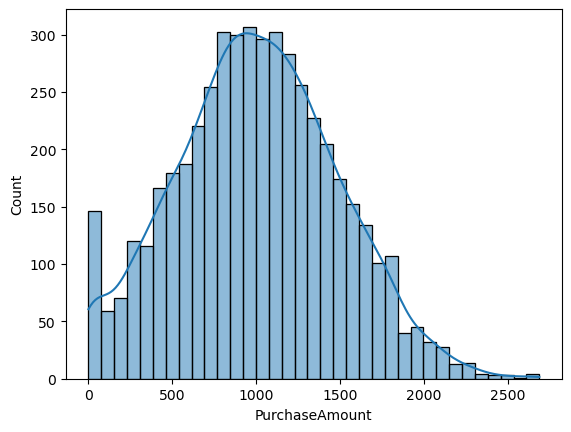

In [14]:
sns.histplot(df["PurchaseAmount"], kde=True)
plt.show()

9. What insights can we gain by applying the Central Limit Theorem?


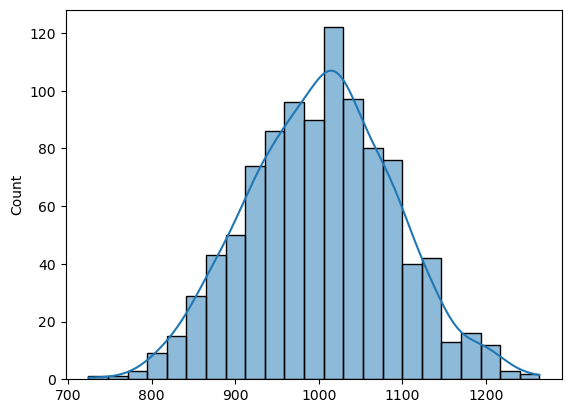

In [15]:
sample_means = []
 
for i in range(1000):
    sample = df["PurchaseAmount"].sample(30)
    sample_means.append(sample.mean())
 
sns.histplot(sample_means, kde=True)
plt.show()

In [16]:
print("Population Mean:", df["PurchaseAmount"].mean())
print("Mean of Sample Means:", np.mean(sample_means))

Population Mean: 1003.9506701030928
Mean of Sample Means: 1002.9644702107231


10.What is the 95% confidence interval for the average PurchaseAmount

In [26]:
data = df["PurchaseAmount"].dropna()
 
mean = data.mean()
n = len(data)
se = data.std() / np.sqrt(n)
 
lower, upper = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=se
)
 
print("Mean:", mean)
print("95% Confidence Interval:", lower, upper)
 

Mean: 1003.9506701030928
95% Confidence Interval: 990.3789594609216 1017.522380745264
